# Stage 2 — PSF convolution, Gaussian noise, and bulge evidence

This stage convolves every intrinsic channel with a known elliptical Gaussian PSF, adds independent Gaussian noise at peak voxel S/N = 10, and compares physical mass models with and without a Hernquist bulge using `dynesty`. The comparison statistic is $\Delta\ln Z = \ln Z_{\rm bulge}-\ln Z_{\rm no\ bulge}$.

In [1]:
import os

# Each process runs one dynesty fit; prevent numerical libraries from creating nested thread pools.
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import multiprocessing as mp
import hashlib
import json
import pickle
import sys
import time
import tomllib
from itertools import product
from pathlib import Path

import dynesty
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from dynesty import plotting as dyplot
from matplotlib.patches import Ellipse

%matplotlib inline

cwd = Path.cwd().resolve()
if (cwd / 'examples' / 'forward_mass').exists():
    REPO_ROOT = cwd
    EXAMPLE_DIR = cwd / 'examples' / 'forward_mass'
elif cwd.name == 'forward_mass':
    EXAMPLE_DIR = cwd
    REPO_ROOT = cwd.parents[1]
else:
    raise FileNotFoundError('Run from the glint repository root or examples/forward_mass.')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from glint.beam import gaussian_psf_kernel
from glint.cosmology import critical_density, kpc_per_arcsec
from glint.forward import convolve_cube_spatial, forward_model_3D_mass_intrinsic, mass_rotation_curve
from glint.mass_model import r200_kpc_from_m200

## Diagnostic plotting helpers

These helper functions are defined before the experiment setup and called after sampling or cache loading. Generated files are written under `output/stage2/`.

In [2]:
def save_dynesty_diagnostic_plots():
    for case in CASES:
        for model_name in ('no_bulge', 'bulge'):
            result = RESULTS[case['name']][model_name]
            result_dir = FIGURE_DIR / case['name'] / model_name
            result_dir.mkdir(parents=True, exist_ok=True)

            run_figure, _ = dyplot.runplot(result['results'], color='tab:blue', logplot=True)
            run_figure.suptitle(f"{case['name']} — {model_name}")
            run_path = result_dir / 'dynesty_runplot.pdf'
            run_figure.savefig(run_path, bbox_inches='tight')
            plt.close(run_figure)

            parameter_names = MODEL_FREE_NAMES[model_name]
            truths = [case[name] for name in parameter_names]
            corner_figure, _ = dyplot.cornerplot(
                result['results'], labels=parameter_names, truths=truths,
                truth_color='tab:red', color='black', show_titles=True,
            )
            corner_figure.suptitle(f"{case['name']} — {model_name}")
            corner_path = result_dir / 'dynesty_cornerplot.pdf'
            corner_figure.savefig(corner_path, bbox_inches='tight')
            plt.close(corner_figure)
            print(f'saved {run_path.relative_to(EXAMPLE_DIR)} and {corner_path.relative_to(EXAMPLE_DIR)}')

### Channel-map and residual helper

The channel-map helper also computes reduced $\chi^2$ and standardized-residual statistics for every case/model.

In [3]:
def save_channel_diagnostics():
    diagnostic_rows = []
    image_extent = [axis.min(), axis.max(), axis.min(), axis.max()]
    field_width = axis.max() - axis.min()
    beam_x = axis.min() + 0.12 * field_width
    beam_y = axis.min() + 0.12 * field_width

    for case in CASES:
        mock = MOCKS[case['name']]
        data_cube = mock['data_cube']
        noise_sigma = mock['noise_sigma']
        for model_name in ('no_bulge', 'bulge'):
            result = RESULTS[case['name']][model_name]
            intrinsic_source_cube = intrinsic_cube(result['best_parameters'])
            model_cube = convolve_cube_spatial(intrinsic_source_cube, PSF_KERNEL)
            residual_sigma_cube = (data_cube - model_cube) / noise_sigma
            fitted_residual = residual_sigma_cube[FIT_MASK]
            n_parameters = len(MODEL_FREE_NAMES[model_name])
            degrees_of_freedom = fitted_residual.size - n_parameters
            chi2 = float(np.sum(fitted_residual**2))
            reduced_chi2 = chi2 / degrees_of_freedom
            diagnostic_rows.append((
                case['name'], model_name, chi2, degrees_of_freedom, reduced_chi2,
                float(np.mean(fitted_residual)), float(np.std(fitted_residual)),
                float(np.max(np.abs(fitted_residual))),
            ))

            result_dir = FIGURE_DIR / case['name'] / model_name
            result_dir.mkdir(parents=True, exist_ok=True)
            n_channels = len(VELOCITY_CHANNELS_KMS)
            figure, axes = plt.subplots(n_channels, 4, figsize=(8.5, 1.65 * n_channels), squeeze=False)
            figure.subplots_adjust(wspace=0.02, hspace=0.02, top=0.96)
            observed_vmin = -2.0 * noise_sigma
            observed_vmax = max(float(np.max(data_cube)), float(np.max(model_cube)))
            source_vmax = float(np.max(intrinsic_source_cube))

            for channel_index, velocity_kms in enumerate(VELOCITY_CHANNELS_KMS):
                panels = (
                    (data_cube[channel_index], 'magma', observed_vmin, observed_vmax),
                    (model_cube[channel_index], 'magma', observed_vmin, observed_vmax),
                    (residual_sigma_cube[channel_index], 'coolwarm', -5.0, 5.0),
                    (intrinsic_source_cube[channel_index], 'magma', 0.0, source_vmax),
                )
                for column, (panel, cmap, vmin, vmax) in enumerate(panels):
                    axes[channel_index, column].imshow(panel, origin='lower', extent=image_extent, cmap=cmap, vmin=vmin, vmax=vmax)
                    axes[channel_index, column].set_xticks([])
                    axes[channel_index, column].set_yticks([])
                axes[channel_index, 0].text(0.03, 0.92, f'{velocity_kms:+.0f} km/s', transform=axes[channel_index, 0].transAxes, color='white', fontsize=7, va='top')
                for column in (0, 1):
                    axes[channel_index, column].add_patch(Ellipse(
                        (beam_x, beam_y), width=CONFIG['psf']['fwhm_major_arcsec'],
                        height=CONFIG['psf']['fwhm_minor_arcsec'], angle=CONFIG['psf']['position_angle_deg'],
                        facecolor='white', edgecolor='black', linewidth=0.4,
                    ))

            for axis_object, title in zip(axes[0], ('True data (noisy)', 'Model data', r'Residual / $\sigma$', 'Reconstructed source'), strict=True):
                axis_object.set_title(title, fontsize=10)
            figure.suptitle(
                f"{case['name']} — {model_name}; reduced chi-square = {reduced_chi2:.3f}",
                fontsize=10,
                y=0.995,
            )
            channel_path = result_dir / 'all_channel_cube_comparison.pdf'
            figure.savefig(channel_path, bbox_inches='tight', pad_inches=0.03)
            plt.close(figure)
            print(f'saved {channel_path.relative_to(EXAMPLE_DIR)}')

    FIT_DIAGNOSTICS = Table(
        rows=diagnostic_rows,
        names=('case', 'model', 'chi2', 'dof', 'reduced_chi2', 'residual_mean_sigma', 'residual_std_sigma', 'max_abs_residual_sigma'),
    )
    for name in FIT_DIAGNOSTICS.colnames[2:]:
        FIT_DIAGNOSTICS[name].format = '.5g'
    diagnostics_path = OUTPUT_DIR / 'fit_diagnostics.csv'
    FIT_DIAGNOSTICS.write(diagnostics_path, format='ascii.csv', overwrite=True)
    display(FIT_DIAGNOSTICS)
    print(f'saved {diagnostics_path.relative_to(EXAMPLE_DIR)}')
    return FIT_DIAGNOSTICS

## Configuration and numerical grid

In [4]:
with (EXAMPLE_DIR / 'mock_stage2.toml').open('rb') as handle:
    CONFIG = tomllib.load(handle)

SOURCE_REDSHIFT = float(CONFIG['target']['redshift'])
KPC_PER_ARCSEC = kpc_per_arcsec(SOURCE_REDSHIFT)
RHO_CRITICAL_MSUN_KPC3 = critical_density(SOURCE_REDSHIFT)
HALO_CONCENTRATION_200 = float(CONFIG['mass_model']['halo_concentration_200'])
mass_cfg, source_cfg, cube_cfg = CONFIG['mass_model'], CONFIG['source'], CONFIG['cube']
noise_cfg, dynesty_cfg = CONFIG['noise'], CONFIG['dynesty']
parallel_cfg = CONFIG['parallel']
OUTPUT_DIR = EXAMPLE_DIR / 'output' / 'stage2'
CACHE_DIR = OUTPUT_DIR / 'cache'
FIGURE_DIR = OUTPUT_DIR / 'figures'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ALL_PARAMETER_NAMES = ('log10_m_baryon', 'bulge_to_total', 'disk_scale_radius_kpc', 'bulge_effective_radius_kpc', 'log10_m200')
MODEL_FREE_NAMES = {
    'bulge': tuple(CONFIG['fit']['free_parameters_bulge']),
    'no_bulge': tuple(CONFIG['fit']['free_parameters_no_bulge']),
}
BOUNDS = CONFIG['fit']['bounds']

axis = (np.arange(cube_cfg['grid_size']) - (cube_cfg['grid_size'] - 1) / 2) * cube_cfg['pixel_size_arcsec']
XX_ARCSEC, YY_ARCSEC = np.meshgrid(axis, axis)
RADIUS_ARCSEC = np.linspace(0.0, cube_cfg['radius_max_arcsec'], cube_cfg['radial_samples'])
RADIUS_KPC = RADIUS_ARCSEC * KPC_PER_ARCSEC
VELOCITY_CHANNELS_KMS = np.arange(cube_cfg['velocity_min_kms'], cube_cfg['velocity_max_kms'] + 0.5 * cube_cfg['channel_width_kms'], cube_cfg['channel_width_kms'])
SPATIAL_MASK = np.hypot(XX_ARCSEC, YY_ARCSEC) <= cube_cfg['radius_max_arcsec']
FIT_MASK = np.broadcast_to(SPATIAL_MASK, (VELOCITY_CHANNELS_KMS.size, *SPATIAL_MASK.shape))
PSF_KERNEL = gaussian_psf_kernel(pixel_size_arcsec=cube_cfg['pixel_size_arcsec'], **CONFIG['psf'])

print(f'z={SOURCE_REDSHIFT:.3f}, scale={KPC_PER_ARCSEC:.4f} kpc/arcsec')
print(f'cube={VELOCITY_CHANNELS_KMS.size} x {cube_cfg["grid_size"]} x {cube_cfg["grid_size"]}; fitted voxels={FIT_MASK.sum():,}')
print(f'PSF kernel={PSF_KERNEL.shape}, sum={PSF_KERNEL.sum():.8f}')
print(f'dynesty: nlive={dynesty_cfg["nlive"]}, dlogz={dynesty_cfg["dlogz"]}')
print(f'parallel: up to {parallel_cfg["max_workers"]} workers ({parallel_cfg["start_method"]} start method)')

z=6.024, scale=5.6972 kpc/arcsec
cube=27 x 65 x 65; fitted voxels=86,643
PSF kernel=(23, 23), sum=1.00000000
dynesty: nlive=150, dlogz=0.3
parallel: up to 32 workers (fork start method)


## Cases and forward model

The source geometry, surface-brightness profile, velocity dispersion, cosmology, and $c_{200}=3$ are fixed. Only the listed mass parameters are sampled.

In [5]:
def case_name(bulge_to_total, bulge_effective_radius_kpc):
    return f'bt{round(100 * bulge_to_total):02d}_re{round(10 * bulge_effective_radius_kpc):02d}'

def make_cases():
    cases = [{
        'name': case_name(bt, re_kpc),
        'log10_m_baryon': np.log10(mass_cfg['total_baryonic_mass_msun']),
        'bulge_to_total': float(bt),
        'disk_scale_radius_kpc': float(mass_cfg['disk_scale_radius_kpc']),
        'bulge_effective_radius_kpc': float(re_kpc),
        'log10_m200': np.log10(mass_cfg['halo_mass_200_msun']),
    } for bt, re_kpc in product(mass_cfg['bulge_to_total_values'], mass_cfg['bulge_effective_radii_kpc'])]
    if mass_cfg.get('include_no_bulge_case', False):
        cases.append({
            'name': 'bt00',
            'log10_m_baryon': np.log10(mass_cfg['total_baryonic_mass_msun']),
            'bulge_to_total': 0.0,
            'disk_scale_radius_kpc': float(mass_cfg['disk_scale_radius_kpc']),
            # Positive placeholder required by the common forward-model signature; physically irrelevant at zero bulge mass.
            'bulge_effective_radius_kpc': float(mass_cfg['no_bulge_placeholder_radius_kpc']),
            'log10_m200': np.log10(mass_cfg['halo_mass_200_msun']),
        })
    return tuple(cases)

CASES = make_cases()

SURFACE_BRIGHTNESS = np.exp(-RADIUS_ARCSEC / source_cfg['surface_brightness_scale_arcsec'])
VELOCITY_DISPERSION = np.full_like(RADIUS_ARCSEC, source_cfg['velocity_dispersion_kms'])

def physical_keywords(parameters):
    baryonic_mass = 10.0 ** parameters['log10_m_baryon']
    bulge_mass = parameters['bulge_to_total'] * baryonic_mass
    halo_mass = 10.0 ** parameters['log10_m200']
    return {
        'disk_mass_msun': baryonic_mass - bulge_mass,
        'disk_scale_radius_kpc': parameters['disk_scale_radius_kpc'],
        'bulge_mass_msun': bulge_mass,
        'bulge_effective_radius_kpc': parameters['bulge_effective_radius_kpc'],
        'halo_mass_200_msun': halo_mass,
        'halo_radius_200_kpc': r200_kpc_from_m200(halo_mass, RHO_CRITICAL_MSUN_KPC3),
        'halo_concentration_200': HALO_CONCENTRATION_200,
    }

def intrinsic_cube(parameters):
    return forward_model_3D_mass_intrinsic(
        xx_arcsec=XX_ARCSEC, yy_arcsec=YY_ARCSEC, radius_arcsec=RADIUS_ARCSEC,
        kpc_per_arcsec=KPC_PER_ARCSEC, velocity_channels_kms=VELOCITY_CHANNELS_KMS,
        surface_brightness_profile=SURFACE_BRIGHTNESS,
        velocity_dispersion_profile_kms=VELOCITY_DISPERSION,
        inclination_deg=source_cfg['inclination_deg'], position_angle_deg=source_cfg['position_angle_deg'],
        systemic_velocity_kms=source_cfg['systemic_velocity_kms'],
        spectral_resolution_sigma_kms=cube_cfg['spectral_resolution_sigma_kms'],
        radius_max_arcsec=cube_cfg['radius_max_arcsec'], **physical_keywords(parameters),
    )

def observed_model_cube(parameters):
    return convolve_cube_spatial(intrinsic_cube(parameters), PSF_KERNEL)

def rotation_curve(parameters):
    return mass_rotation_curve(radius_kpc=RADIUS_KPC, **physical_keywords(parameters))

Table(rows=[(c['name'], c['bulge_to_total'], c['bulge_effective_radius_kpc']) for c in CASES], names=('case', 'B/T', 'Re_bulge_kpc'))

case,B/T,Re_bulge_kpc
str9,float64,float64
bt10_re03,0.1,0.3
bt10_re06,0.1,0.6
bt25_re03,0.25,0.3
bt25_re06,0.25,0.6
bt50_re03,0.5,0.3
bt50_re06,0.5,0.6
bt00,0.0,0.3


## Fixed mock realizations

Noise RMS is defined from the maximum voxel of the PSF-convolved noiseless cube. Each physical case gets a reproducible, independent noise realization; the identical data cube is used for both competing models.

In [6]:
MOCKS = {}
for case_index, case in enumerate(CASES):
    noiseless_cube = observed_model_cube(case)
    noise_sigma = float(noiseless_cube.max() / noise_cfg['peak_signal_to_noise'])
    rng = np.random.default_rng(np.random.SeedSequence([noise_cfg['random_seed'], case_index]))
    data_cube = noiseless_cube + rng.normal(0.0, noise_sigma, noiseless_cube.shape)
    MOCKS[case['name']] = {'noiseless_cube': noiseless_cube, 'data_cube': data_cube, 'noise_sigma': noise_sigma}
    print(case['name'], f'noise sigma={noise_sigma:.4g}', f'realized peak S/N={noiseless_cube.max()/noise_sigma:.1f}')

bt10_re03 noise sigma=0.01829 realized peak S/N=10.0
bt10_re06 noise sigma=0.01725 realized peak S/N=10.0
bt25_re03 noise sigma=0.01876 realized peak S/N=10.0
bt25_re06 noise sigma=0.01907 realized peak S/N=10.0
bt50_re03 noise sigma=0.01659 realized peak S/N=10.0
bt50_re06 noise sigma=0.02007 realized peak S/N=10.0
bt00 noise sigma=0.01569 realized peak S/N=10.0


## Likelihood, priors, and timing benchmark

Both models use uniform priors from the TOML file. The no-bulge model fixes $B/T=0$ and removes the now-meaningless bulge radius from its parameter space. The Gaussian normalization is retained in $\ln L$, although it cancels in the evidence difference.

In [7]:
def complete_parameters(theta, case, model_name):
    parameters = {name: float(case[name]) for name in ALL_PARAMETER_NAMES}
    if model_name == 'no_bulge':
        parameters['bulge_to_total'] = 0.0
    parameters.update(zip(MODEL_FREE_NAMES[model_name], np.asarray(theta, dtype=float), strict=True))
    return parameters

def prior_transform(unit_cube, model_name):
    names = MODEL_FREE_NAMES[model_name]
    lower = np.array([BOUNDS[name]['lower'] for name in names])
    upper = np.array([BOUNDS[name]['upper'] for name in names])
    return lower + np.asarray(unit_cube) * (upper - lower)

def make_loglikelihood(case, model_name):
    mock = MOCKS[case['name']]
    data = mock['data_cube'][FIT_MASK]
    sigma = mock['noise_sigma']
    log_normalization = data.size * np.log(2.0 * np.pi * sigma**2)
    def loglikelihood(theta):
        model = observed_model_cube(complete_parameters(theta, case, model_name))[FIT_MASK]
        chi2 = np.sum(((data - model) / sigma) ** 2)
        return -0.5 * (chi2 + log_normalization)
    return loglikelihood

benchmark_loglike = make_loglikelihood(CASES[0], 'bulge')
benchmark_rng = np.random.default_rng(1234)
benchmark_points = [prior_transform(benchmark_rng.random(len(MODEL_FREE_NAMES['bulge'])), 'bulge') for _ in range(30)]
start = time.perf_counter()
for point in benchmark_points:
    benchmark_loglike(point)
SECONDS_PER_LOGLIKE = (time.perf_counter() - start) / len(benchmark_points)
print(f'{1e3 * SECONDS_PER_LOGLIKE:.2f} ms per likelihood evaluation ({1/SECONDS_PER_LOGLIKE:.1f} evaluations/s, one core)')

5.32 ms per likelihood evaluation (187.8 evaluations/s, one core)


## Nested sampling

Each case/model result is cached under `output/stage2/cache/`. A valid cache is loaded automatically, so repeated executions skip nested sampling and only regenerate tables and figures. Changes to the sampling configuration or relevant `glint` source invalidate the cache. Set `STAGE2_FORCE_REFIT=1` to ignore valid caches, `STAGE2_BENCHMARK_ONLY=1` to skip both sampling and cache loading, `STAGE2_MAX_CASES=1` to limit cases, or `STAGE2_MODELS=bulge` to select models. A normal execution runs all configured cases, including the optional B/T=0 mock, with both models. Only load cache files created by this notebook, because pickle files are not safe when obtained from an untrusted source.

In [8]:
def weighted_quantile(values, quantiles, weights):
    order = np.argsort(values)
    sorted_values = np.asarray(values)[order]
    cumulative = np.cumsum(np.asarray(weights)[order])
    cumulative /= cumulative[-1]
    return np.interp(quantiles, cumulative, sorted_values)

def run_nested_fit(case, model_name, task_seed):
    names = MODEL_FREE_NAMES[model_name]
    loglikelihood = make_loglikelihood(case, model_name)
    sampler = dynesty.NestedSampler(
        loglikelihood, lambda u: prior_transform(u, model_name), len(names),
        nlive=dynesty_cfg['nlive'], bound=dynesty_cfg['bound'], sample=dynesty_cfg['sample'],
        rstate=np.random.default_rng(np.random.SeedSequence([dynesty_cfg['random_seed'], task_seed])),
    )
    start = time.perf_counter()
    sampler.run_nested(dlogz=dynesty_cfg['dlogz'], print_progress=False)
    elapsed = time.perf_counter() - start
    results = sampler.results
    weights = np.exp(results.logwt - results.logz[-1])
    posterior = {}
    for column, name in enumerate(names):
        posterior[name] = weighted_quantile(results.samples[:, column], [0.16, 0.50, 0.84], weights)
    best_index = int(np.argmax(results.logl))
    return {
        'results': results, 'weights': weights, 'posterior': posterior,
        'best_parameters': complete_parameters(results.samples[best_index], case, model_name),
        'logz': float(results.logz[-1]), 'logzerr': float(results.logzerr[-1]),
        'max_logl': float(results.logl[best_index]), 'ncall': int(np.sum(results.ncall)), 'elapsed_seconds': elapsed,
    }

def run_nested_task(task):
    case, model_name, task_seed = task
    return case['name'], model_name, run_nested_fit(case, model_name, task_seed)

CACHE_VERSION = 1
SAMPLING_CONFIG_SECTIONS = ('target', 'source', 'cube', 'psf', 'noise', 'fit', 'dynesty')
SAMPLING_SOURCE_FILES = ('cosmology.py', 'mass_model.py', 'source.py', 'forward.py', 'beam.py')

def stable_task_seed(case_name, model_name):
    digest = hashlib.sha256(f'{case_name}:{model_name}'.encode()).digest()
    return int.from_bytes(digest[:4], byteorder='little')

def update_with_code_content(digest, code):
    # Deliberately exclude co_filename and line numbers, which change between Jupyter kernels.
    digest.update(code.co_code)
    digest.update(repr(code.co_names).encode())
    digest.update(repr(code.co_varnames).encode())
    for constant in code.co_consts:
        if isinstance(constant, type(code)):
            update_with_code_content(digest, constant)
        else:
            digest.update(repr(constant).encode())

def sampling_fingerprint(case, model_name):
    payload = {
        'cache_version': CACHE_VERSION,
        'config': {section: CONFIG[section] for section in SAMPLING_CONFIG_SECTIONS},
        'case': case,
        'model_name': model_name,
        'dynesty_version': dynesty.__version__,
        'numpy_version': np.__version__,
    }
    digest = hashlib.sha256(json.dumps(payload, sort_keys=True, default=lambda value: value.item() if isinstance(value, np.generic) else str(value)).encode())
    for function in (physical_keywords, intrinsic_cube, observed_model_cube, complete_parameters, prior_transform, make_loglikelihood, run_nested_fit):
        update_with_code_content(digest, function.__code__)
    for filename in SAMPLING_SOURCE_FILES:
        digest.update((REPO_ROOT / 'glint' / filename).read_bytes())
    return digest.hexdigest()

def cache_path(case_name, model_name):
    return CACHE_DIR / f'{case_name}__{model_name}.pkl'

def load_cached_result(case_name, model_name, fingerprint):
    path = cache_path(case_name, model_name)
    if not path.exists():
        return None
    try:
        with path.open('rb') as handle:
            payload = pickle.load(handle)
    except (OSError, EOFError, pickle.UnpicklingError):
        return None
    return payload['result'] if payload.get('fingerprint') == fingerprint else None

def save_cached_result(case_name, model_name, fingerprint, result):
    path = cache_path(case_name, model_name)
    temporary_path = path.with_suffix('.tmp')
    with temporary_path.open('wb') as handle:
        pickle.dump({'fingerprint': fingerprint, 'result': result}, handle, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(temporary_path, path)

RESULTS = {}
BENCHMARK_ONLY = os.getenv('STAGE2_BENCHMARK_ONLY', '0') == '1'
if not BENCHMARK_ONLY:
    max_cases = int(os.getenv('STAGE2_MAX_CASES', str(len(CASES))))
    run_models = tuple(name.strip() for name in os.getenv('STAGE2_MODELS', 'no_bulge,bulge').split(','))
    if not set(run_models) <= set(MODEL_FREE_NAMES):
        raise ValueError(f'Unknown STAGE2_MODELS value: {run_models}')
    run_cases = CASES[:max_cases]
    force_refit = os.getenv('STAGE2_FORCE_REFIT', '0') == '1'
    tasks = []
    fingerprints = {}
    for case, model_name in product(run_cases, run_models):
        key = (case['name'], model_name)
        fingerprint = sampling_fingerprint(case, model_name)
        fingerprints[key] = fingerprint
        cached_result = None if force_refit else load_cached_result(*key, fingerprint)
        if cached_result is None:
            tasks.append((case, model_name, stable_task_seed(*key)))
        else:
            RESULTS.setdefault(case['name'], {})[model_name] = cached_result
            print(f'{case["name"]:10s} {model_name:9s}: loaded valid cache')
    total_start = time.perf_counter()
    if tasks:
        available_cpus = os.cpu_count() or 1
        configured_workers = int(parallel_cfg['max_workers'])
        max_workers = min(configured_workers, available_cpus, len(tasks))
        print(f'running {len(tasks)} cache-miss fits with {max_workers} worker processes')
        if max_workers == 1:
            completed_tasks = map(run_nested_task, tasks)
            pool = None
        else:
            context = mp.get_context(parallel_cfg['start_method'])
            pool = context.Pool(processes=max_workers)
            completed_tasks = pool.imap_unordered(run_nested_task, tasks, chunksize=1)
        try:
            for case_name, model_name, result in completed_tasks:
                RESULTS.setdefault(case_name, {})[model_name] = result
                save_cached_result(case_name, model_name, fingerprints[(case_name, model_name)], result)
                print(f"{case_name:10s} {model_name:9s}: lnZ={result['logz']:.2f} +/- {result['logzerr']:.2f}, calls={result['ncall']:,}, fit time={result['elapsed_seconds']/60:.1f} min; cache saved")
        finally:
            if pool is not None:
                pool.close()
                pool.join()
    else:
        print('all requested fits loaded from valid caches; dynesty sampling skipped')
    print(f'total sampling/cache wall time = {(time.perf_counter()-total_start)/60:.2f} min')
else:
    print('Benchmark-only mode: nested sampling skipped.')

bt10_re03  no_bulge : loaded valid cache
bt10_re03  bulge    : loaded valid cache
bt10_re06  no_bulge : loaded valid cache
bt10_re06  bulge    : loaded valid cache
bt25_re03  no_bulge : loaded valid cache
bt25_re03  bulge    : loaded valid cache
bt25_re06  no_bulge : loaded valid cache
bt25_re06  bulge    : loaded valid cache
bt50_re03  no_bulge : loaded valid cache
bt50_re03  bulge    : loaded valid cache
bt50_re06  no_bulge : loaded valid cache
bt50_re06  bulge    : loaded valid cache
bt00       no_bulge : loaded valid cache
bt00       bulge    : loaded valid cache
all requested fits loaded from valid caches; dynesty sampling skipped
total sampling/cache wall time = 0.00 min


## Evidence and parameter summary

case,B/T truth,Re truth [kpc],lnZ no bulge,lnZ bulge,Delta lnZ,Delta lnZ numerical error
str9,float64,float64,float64,float64,float64,float64
bt10_re03,0.100,0.300,223286.107,223532.942,246.835,0.637
bt10_re06,0.100,0.600,228651.448,228731.628,80.180,0.614
bt25_re03,0.250,0.300,221161.359,221665.373,504.014,0.642
bt25_re06,0.250,0.600,219689.201,219934.170,244.968,0.640
bt50_re03,0.500,0.300,231062.769,231793.751,730.983,0.659
bt50_re06,0.500,0.600,215483.436,215791.543,308.107,0.620
bt00,0.000,0.300,236949.217,236944.910,-4.306,0.598


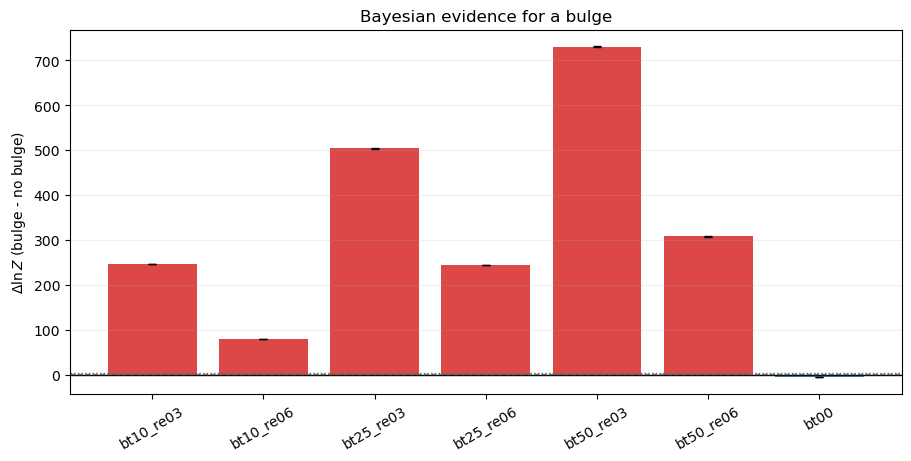

In [9]:
FULL_RESULTS = len(RESULTS) == len(CASES) and all(set(result) == {'no_bulge', 'bulge'} for result in RESULTS.values())
if FULL_RESULTS:
    rows = []
    for case in CASES:
        no_bulge = RESULTS[case['name']]['no_bulge']
        bulge = RESULTS[case['name']]['bulge']
        rows.append((case['name'], case['bulge_to_total'], case['bulge_effective_radius_kpc'], no_bulge['logz'], bulge['logz'], bulge['logz'] - no_bulge['logz'], np.hypot(no_bulge['logzerr'], bulge['logzerr'])))
    EVIDENCE_TABLE = Table(rows=rows, names=('case', 'B/T truth', 'Re truth [kpc]', 'lnZ no bulge', 'lnZ bulge', 'Delta lnZ', 'Delta lnZ numerical error'))
    for name in EVIDENCE_TABLE.colnames[1:]: EVIDENCE_TABLE[name].format = '.3f'
    display(EVIDENCE_TABLE)

    fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
    delta = np.asarray(EVIDENCE_TABLE['Delta lnZ'])
    error = np.asarray(EVIDENCE_TABLE['Delta lnZ numerical error'])
    colors = ['tab:blue' if value < 2.5 else 'tab:orange' if value < 5 else 'tab:red' for value in delta]
    ax.bar(np.arange(len(CASES)), delta, yerr=error, color=colors, alpha=0.85, capsize=3)
    ax.axhline(0, color='black', lw=1)
    ax.axhline(2.5, color='0.4', lw=1, ls='--')
    ax.axhline(5.0, color='0.4', lw=1, ls=':')
    ax.set_xticks(np.arange(len(CASES)), [case['name'] for case in CASES], rotation=30)
    ax.set_ylabel(r'$\Delta\ln Z$ (bulge - no bulge)')
    ax.set_title('Bayesian evidence for a bulge')
    ax.grid(axis='y', alpha=0.2)
    plt.show()

## Rotation curves and residual diagnostics

Solid black is the truth, red is the maximum-likelihood bulge model, and blue is the maximum-likelihood no-bulge model. Residual moment maps are summed over velocity after subtracting the corresponding convolved model cube.

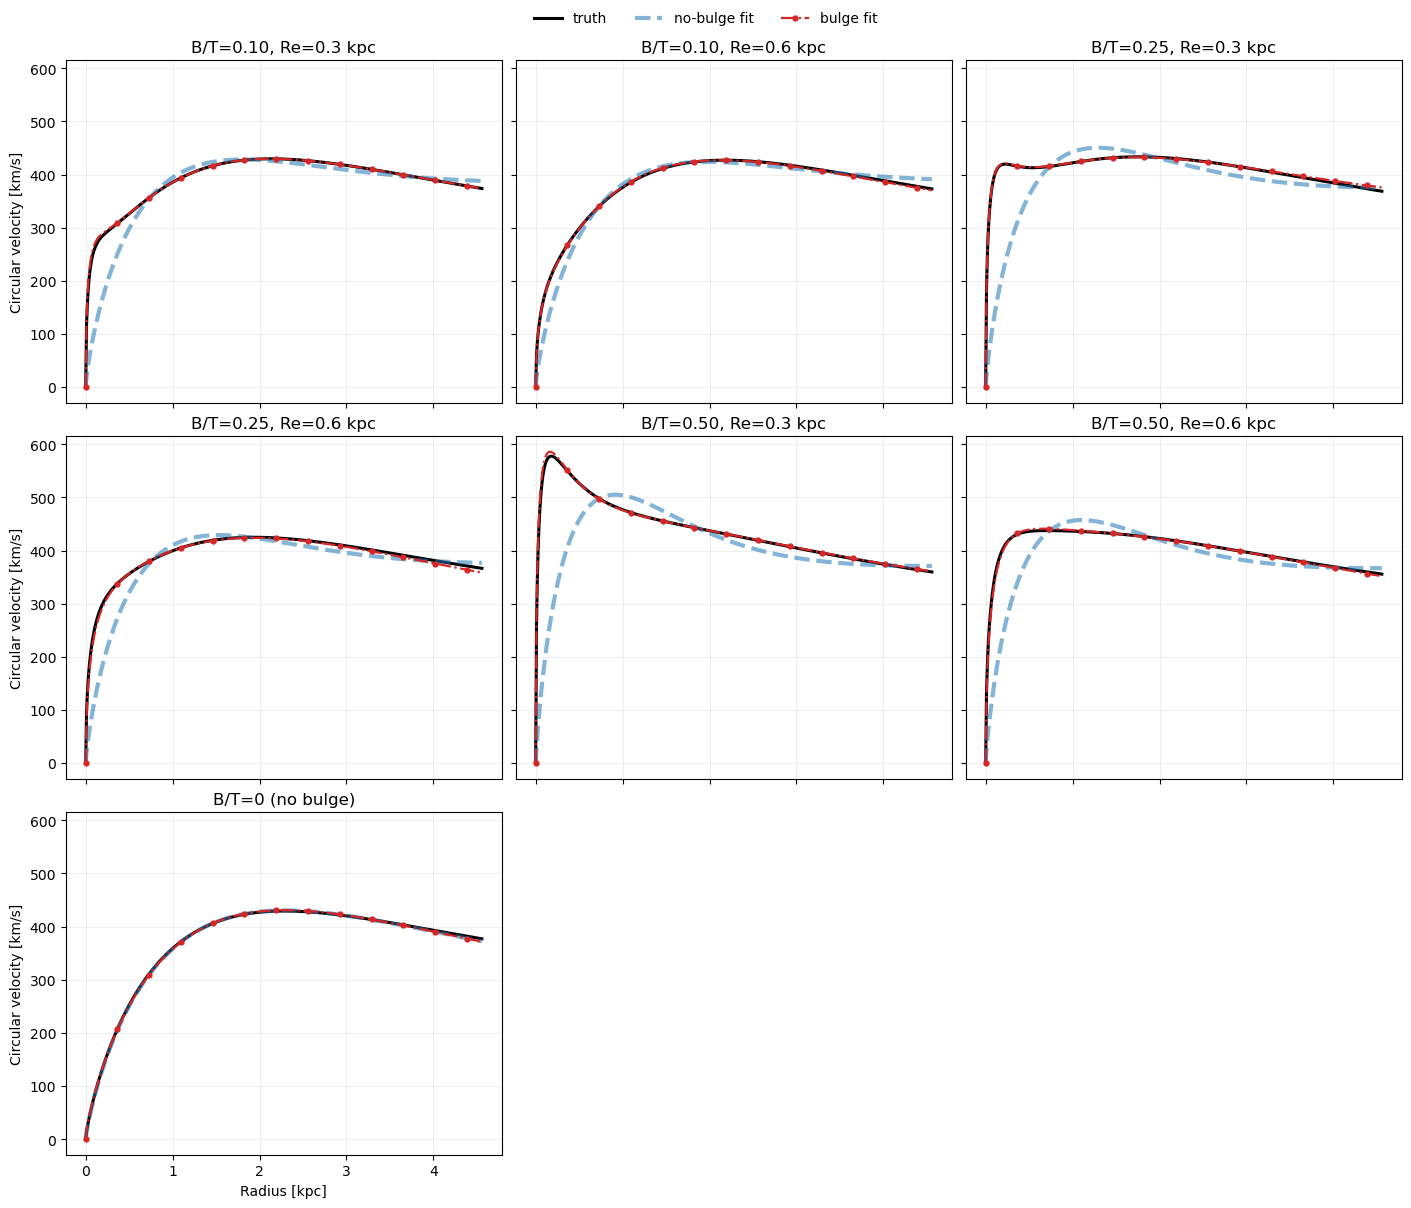

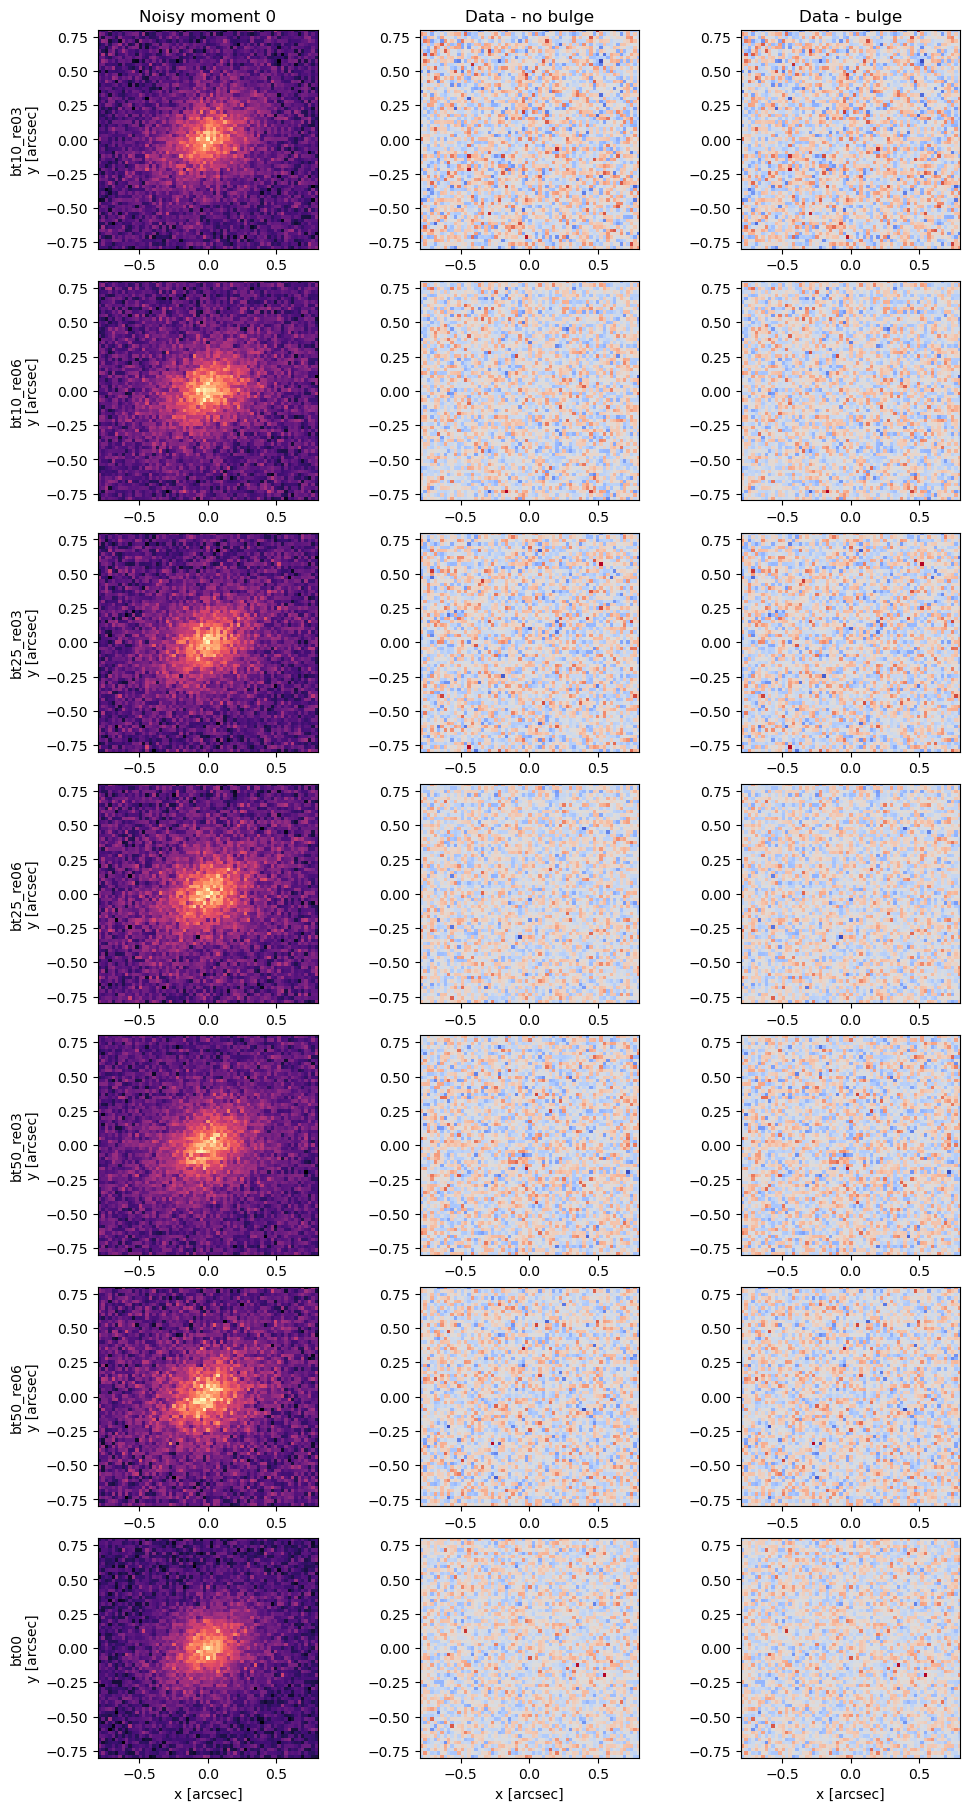

In [10]:
if FULL_RESULTS:
    ncols = 3
    nrows = int(np.ceil(len(CASES) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True, sharey=True, squeeze=False, constrained_layout=True)
    for ax, case in zip(axes.flat, CASES):
        ax.plot(RADIUS_KPC, rotation_curve(case)['total_kms'], color='black', lw=2.2, label='truth')
        fit_styles = {
            'no_bulge': dict(color='tab:blue', lw=3.0, ls='--', alpha=0.55, zorder=2, label='no-bulge fit'),
            'bulge': dict(color='tab:red', lw=1.6, ls='-.', marker='o', markevery=40, ms=3.5, zorder=3, label='bulge fit'),
        }
        # Draw the broad no-bulge curve first and the marked bulge curve last so coincident fits remain visible.
        for model_name in ('no_bulge', 'bulge'):
            curve = rotation_curve(RESULTS[case['name']][model_name]['best_parameters'])
            ax.plot(RADIUS_KPC, curve['total_kms'], **fit_styles[model_name])
        title = 'B/T=0 (no bulge)' if case['bulge_to_total'] == 0 else f"B/T={case['bulge_to_total']:.2f}, Re={case['bulge_effective_radius_kpc']:.1f} kpc"
        ax.set_title(title)
        ax.grid(alpha=0.2)
    for ax in axes.flat[len(CASES):]: ax.set_visible(False)
    for ax in axes[:, 0]: ax.set_ylabel('Circular velocity [km/s]')
    for ax in axes[-1]: ax.set_xlabel('Radius [kpc]')
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside upper center', ncol=3, frameon=False)
    plt.show()

    fig, axes = plt.subplots(len(CASES), 3, figsize=(10, 18), constrained_layout=True)
    extent = [axis.min(), axis.max(), axis.min(), axis.max()]
    for row, case in enumerate(CASES):
        mock = MOCKS[case['name']]
        data_moment0 = mock['data_cube'].sum(axis=0)
        residuals = {}
        for model_name in ('no_bulge', 'bulge'):
            model_cube = observed_model_cube(RESULTS[case['name']][model_name]['best_parameters'])
            residuals[model_name] = (mock['data_cube'] - model_cube).sum(axis=0)
        limit = max(np.max(np.abs(residuals['no_bulge'])), np.max(np.abs(residuals['bulge'])))
        axes[row, 0].imshow(data_moment0, origin='lower', extent=extent, cmap='magma')
        axes[row, 1].imshow(residuals['no_bulge'], origin='lower', extent=extent, cmap='coolwarm', vmin=-limit, vmax=limit)
        axes[row, 2].imshow(residuals['bulge'], origin='lower', extent=extent, cmap='coolwarm', vmin=-limit, vmax=limit)
        axes[row, 0].set_ylabel(case['name'] + '\ny [arcsec]')
    for ax, title in zip(axes[0], ('Noisy moment 0', 'Data - no bulge', 'Data - bulge'), strict=True): ax.set_title(title)
    for ax in axes[-1]: ax.set_xlabel('x [arcsec]')
    plt.show()

## Saved fit and convergence diagnostics

For every case and model, `dynesty.plotting.runplot`, `cornerplot`, and a full 27-channel cube comparison are saved under `output/stage2/figures/<case>/<model>/`. The four cube columns are noisy true observed data, PSF-convolved maximum-likelihood model data, standardized residual $(D-M)/\sigma$, and reconstructed intrinsic source before PSF convolution. A successful noise-limited fit should have residual RMS and reduced $\chi^2$ near one; the residual cube is not expected to be zero because the mock contains noise.

In [11]:
if FULL_RESULTS:
    save_dynesty_diagnostic_plots()
    FIT_DIAGNOSTICS = save_channel_diagnostics()

saved output/stage2/figures/bt10_re03/no_bulge/dynesty_runplot.pdf and output/stage2/figures/bt10_re03/no_bulge/dynesty_cornerplot.pdf


saved output/stage2/figures/bt10_re03/bulge/dynesty_runplot.pdf and output/stage2/figures/bt10_re03/bulge/dynesty_cornerplot.pdf


saved output/stage2/figures/bt10_re06/no_bulge/dynesty_runplot.pdf and output/stage2/figures/bt10_re06/no_bulge/dynesty_cornerplot.pdf


saved output/stage2/figures/bt10_re06/bulge/dynesty_runplot.pdf and output/stage2/figures/bt10_re06/bulge/dynesty_cornerplot.pdf


saved output/stage2/figures/bt25_re03/no_bulge/dynesty_runplot.pdf and output/stage2/figures/bt25_re03/no_bulge/dynesty_cornerplot.pdf


...

saved output/stage2/figures/bt50_re06/bulge/all_channel_cube_comparison.pdf


saved output/stage2/figures/bt00/no_bulge/all_channel_cube_comparison.pdf


saved output/stage2/figures/bt00/bulge/all_channel_cube_comparison.pdf


case,model,chi2,dof,reduced_chi2,residual_mean_sigma,residual_std_sigma,max_abs_residual_sigma
str9,str8,float64,int64,float64,float64,float64,float64
bt10_re03,no_bulge,87554,86640,1.0105,0.008375,1.0052,4.6089
bt10_re03,bulge,87060,86638,1.0049,0.008375,1.0024,4.6089
bt10_re06,no_bulge,86927,86640,1.0033,-0.0014242,1.0016,4.731
bt10_re06,bulge,86764,86638,1.0015,-0.0014242,1.0007,4.706
bt25_re03,no_bulge,87359,86640,1.0083,-0.0035805,1.0041,4.8799
bt25_re03,bulge,86355,86638,0.99673,-0.0035805,0.99833,4.759
bt25_re06,no_bulge,87509,86640,1.01,-0.00024398,1.005,4.1382
bt25_re06,bulge,87022,86638,1.0044,-0.00024398,1.0022,4.1382
bt50_re03,no_bulge,88908,86640,1.0262,-0.00077043,1.013,4.7157


saved output/stage2/fit_diagnostics.csv


## Interpretation

For the B/T=0 mock, the no-bulge model should normally be favored after the evidence penalizes the two unnecessary bulge parameters. Its configured bulge radius is only a positive placeholder and has no physical meaning. A small $\Delta\ln Z$ for a true bulge does not by itself indicate a code failure: at finite resolution and S/N, a compact or low-mass bulge can be absorbed by disk and halo parameters. Evidence is prior-dependent, so the numerical result must always be quoted together with `mock_stage2.toml`.